<a href="https://colab.research.google.com/github/nomanabdullah04/MaChineLearning/blob/MachineLearning/SimpleLinerProjct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# You can have to follow those step for Running a machine   Learing Project

---




Phase 1: Business Understanding & Problem Framing
Before writing code, define the business goal and translate it into a technical problem.
- Define success: Set clear metrics (e.g., reduce customer churn by 5%, achieve 95% fraud detection).
- Identify project type: Determine if it is a classification, regression, clustering, or generative AI problem.
- Assess constraints: Check data availability, project budget, time limits, and hardware constraints.

Phase 2: Data Collection & Ingestion
Gather the raw data required to solve the framed problem.
- Identify sources: Locate databases, APIs, CSV files, web scraping targets, or IoT sensor streams.
- Data storage: Store raw data securely in a data lake (e.g., AWS S3) or a data warehouse (e.g., Snowflake).
- Data versioning: Use tools like DVC (Data Version Control) to track changes in your data files over time.

Phase 3: Data Cleaning & Preprocessing
Prepare the raw data so that machine learning algorithms can read it without crashing.
- Handle missing values: Drop columns with too many blanks, or fill them using averages (mean/median).
- Fix data types: Convert text numbers to numeric types using `pd.to_numeric(..., errors='coerce')`.
- Remove duplicates: Clean out redundant rows to prevent model bias.
- Manage outliers: Filter out extreme, corrupted data points that could distort model training.

Phase 4: Exploratory Data Analysis (EDA)
Analyze the clean data visually and statistically to find patterns, anomalies, and relationships.
- Check distributions: Plot histograms to see how target variables and features are spread out.
- Correlation analysis: Create heatmaps to find which features correlate strongest with your target.
- Visualize anomalies: Use scatter plots and box plots to spot hidden clusters or data shifts.

Phase 5: Feature Engineering & Selection
Transform raw variables into highly informative features that boost model performance.
- Encoding: Turn categorical text (like "Red", "Blue") into numbers using One-Hot or Label Encoding.
- Scaling: Normalize numerical features to a uniform scale (e.g., 0 to 1) using StandardScaler or MinMaxScaler.
- Feature creation: Combine columns to make new ones (e.g., dividing Distance by Time to create a Speed feature).
- Feature selection: Drop highly redundant or useless features to keep the model fast and lightweight.

Phase 6: Model Training & Hyperparameter Tuning
Train candidate models on your processed data to find the best-performing algorithm.
- Data splitting: Divide your data into Training (70%), Validation (15%), and Testing (15%) sets.
- Baseline training: Start with simple algorithms (e.g., Linear Regression, Decision Trees) to set a benchmark.
- Hyperparameter tuning: Use LassoCV, GridSearchCV, or RandomizedSearchCV to fine-tune model settings and find optimal regularization strengths (`alpha_`).
- Cross-Validation: Use K-Fold cross-validation to ensure model performance is stable across different data splits.

Phase 7: Model Evaluation & Validation
Test the finalized model on unseen data to ensure it generalizes well to the real world.
- Classification metrics: Check Accuracy, Precision, Recall, F1-Score, and the ROC-AUC score.
- Regression metrics: Evaluate Mean Absolute Error (MAE), Mean Squared Error (MSE), and \(R^{2}\) Score.
- Overfitting check: Compare training performance against testing performance to ensure the model didn't just memorize the training data.

Phase 8: Model Deployment
Move the trained model out of your notebook and into a production environment where users can access it.
- Model serialization: Save the trained model object as a file using pickle or joblib.
- API creation: Wrap the model file in a web framework like FastAPI or Flask to accept data requests.
- Containerization: Pack the API, model, and code dependencies into a Docker container for consistent deployment.
- Cloud hosting: Deploy the container to a cloud platform (AWS, Google Cloud, Azure) or an ML platform (Hugging Face, SageMaker).

Phase 9: Monitoring & Maintenance
Track the model's health in production and update it when real-world conditions change.
- Monitor performance: Track latency (speed), system errors, and prediction distributions.
- Detect Data Drift: Watch for shifts in incoming real-world data compared to the historical training data.
- CI/CD retraining pipelines: Set up automated scripts to retrain and redeploy the model periodically with fresh data.

# **Now we will build a Simple Linera Regression Project**

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [15]:
df=pd.read_csv('/content/sample_data/SOCR-HeightWeight.csv')

In [16]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [17]:
#Check if there is null value into the dataset
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


In [18]:
#Check if there is any categorical value into the datasset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 586.1 KB


In [19]:
#Define indepedent and Dependent value
x=df.iloc[:,1]
y=df.iloc[:,-1]

In [20]:
x.shape,y.shape

((25000,), (25000,))

In [38]:
x

,Height(Inches)
0,65.78331
1,71.51521
2,69.39874
3,68.21660
4,67.78781
...,...
24995,69.50215
24996,64.54826
24997,64.69855
24998,67.52918


In [39]:
y

,Weight(Pounds)
0,112.9925
1,136.4873
2,153.0269
3,142.3354
4,144.2971
...,...
24995,118.0312
24996,120.1932
24997,118.2655
24998,132.2682


In [21]:
df.describe()

,Index,Height(Inches),Weight(Pounds)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,67.993114,127.079421
std,7217.022701,1.901679,11.660898
min,1.000000,60.278360,78.014760
25%,6250.750000,66.704397,119.308675
50%,12500.500000,67.995700,127.157750
75%,18750.250000,69.272958,134.892850
max,25000.000000,75.152800,170.924000


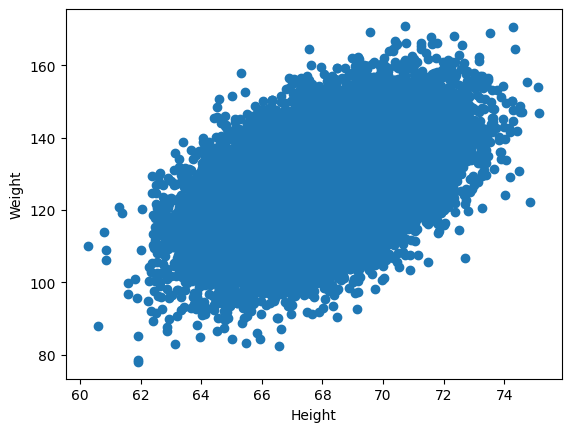

In [23]:
plt.scatter(x,y)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

***Now we will do train_test_split the given data***

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [25]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((20000,), (5000,), (20000,), (5000,))

# **Standradize the dataset**

In [53]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_score=sc.fit_transform(x_train)
x_test_score=sc.transform(x_test)
x_train_score
x_test_score


array([[ 0.22883657],
       [-0.04939933],
       [-0.17454328],
       ...,
       [ 0.30606516],
       [-0.47162905],
       [ 1.35968121]])

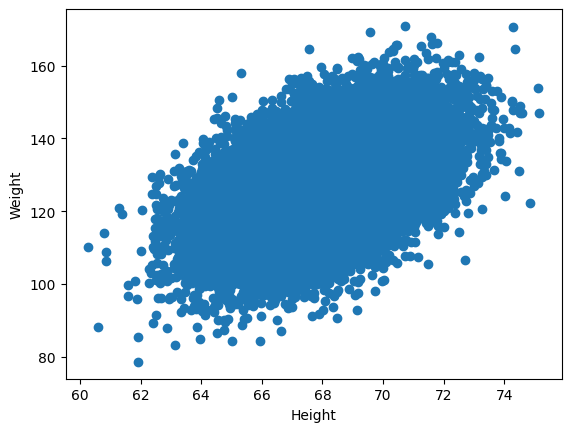

In [37]:
plt.scatter(x_train,y_train)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

**Train the simple Linear Regression Models**

---
Why Reshaping is Required!


Scikit-Learn Expects a ***2D Array for Features (X)***:


  1.Scikit-learn models are built to handle multiple features at once.It strictly expects X to be a 2D shape: (number_of_samples, number_of_features).


  **2.Single Columns Start as 1D Arrays**
When you select a single column from a pandas DataFrame (e.g., X = df['living_area']), Python extracts it as a 1D array with the shape (number_of_samples,).


Because it lacks the second dimension (the column count), the model cannot read it and throws an error.

In [56]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_score.reshape(-1,1),y_train)
print("tHE Correlation of this datastet:",lr.coef_)
print(lr.intercept_)


tHE Correlation of this datastet: [5.82644432]
127.07814619150004


In [43]:
y_pred=lr.predict(x_test_score.reshape(-1,1))
y_pred

array([128.41144971, 126.79032375, 126.06117947, ..., 128.86141782,
       124.33022578, 135.00025306])

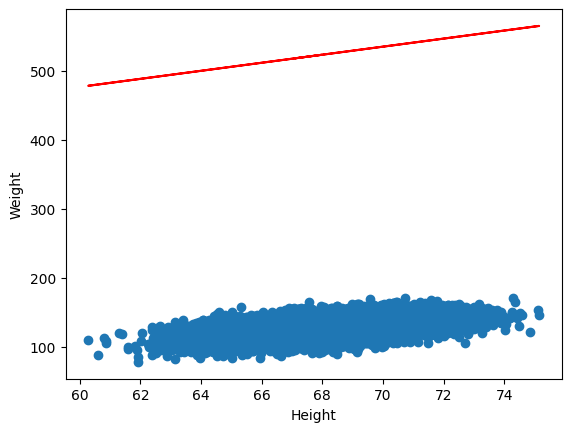

In [45]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train.reshape(-1,1)),color='red')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

In [47]:
#Prediction of train and Test data
y_pred_train=lr.predict(x_train_score.reshape(-1,1))
y_pred_test=lr.predict(x_test_score.reshape(-1,1))
y_pred_test,y_test

(array([128.41144971, 126.79032375, 126.06117947, ..., 128.86141782,
        124.33022578, 135.00025306]),
 6868     134.2855
 24016    111.9666
 9668     135.9871
 13640    126.3802
 14018    100.1810
            ...   
 8670     138.0941
 11839    105.2101
 4013     141.1859
 21147    129.5261
 695      134.7527
 Name: Weight(Pounds), Length: 5000, dtype: float64)

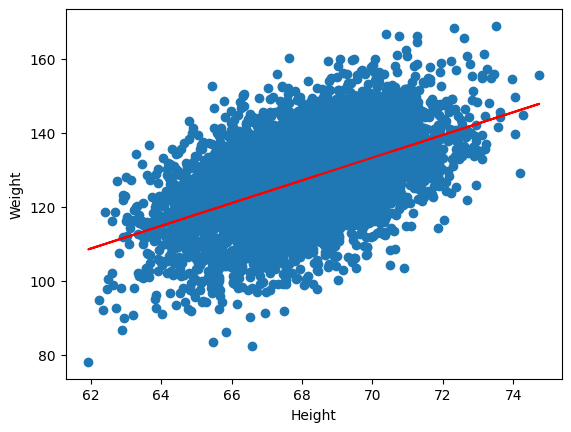

In [48]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred_test,color='red')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

## Performace the Matrix
R square and Adjusted R


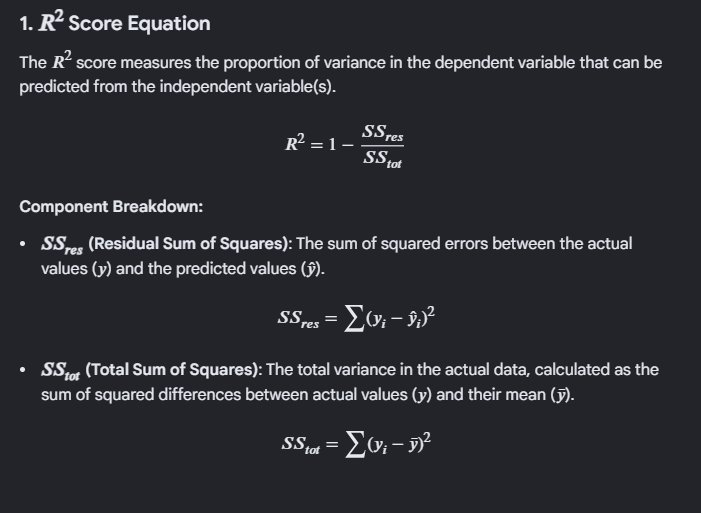


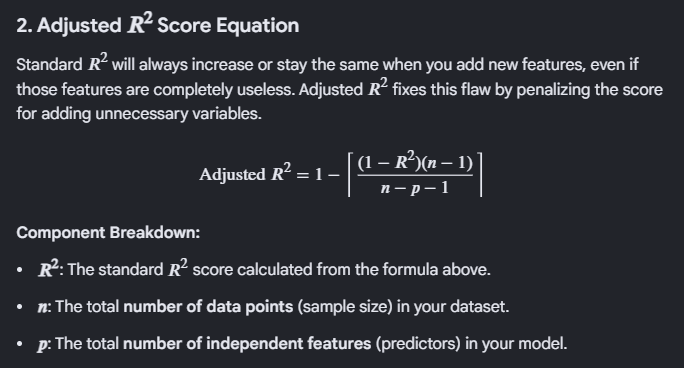

In [49]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
r2=r2_score(y_test,y_pred_test)
print(mse,mae,r2)

102.48790963792534 8.034767997494626 0.26059113512888576


In [50]:
#Adjusted R square
1-(1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.2604431941795319

In [59]:
lr

LinearRegression()

In [60]:
#New data point weight is 80
scaler_weight=sc.transform([[80]])
scaler_weight

array([[6.33054917]])

In [63]:
predicted_weight = lr.predict(scaler_weight)
print(f"Predicted Weight for a height of 80 inches: {predicted_weight[0]:.2f} pounds")

Predicted Weight for a height of 80 inches: 163.96 pounds


# **Assumption**

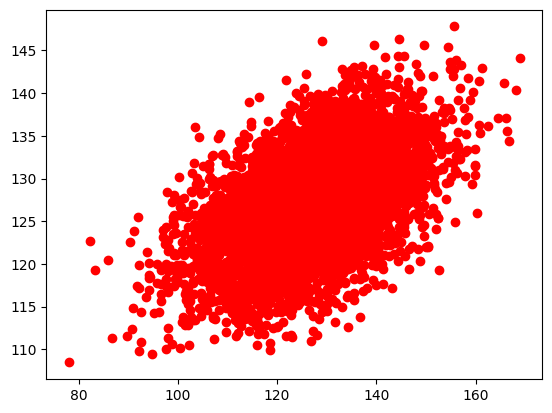

In [64]:
#Plot a csatter plot for the prdiction
plt.scatter(y_test,y_pred_test,color='red')


Assumption: As if its linearly distubuted .You have well predct

In [65]:
#Residuals

residuals=y_test-y_pred_test


In [66]:
residuals

,Weight(Pounds)
6868,5.874050
24016,-14.823724
9668,9.925921
13640,-3.838739
14018,-30.030445
...,...
8670,8.110787
11839,-19.701420
4013,12.324482
21147,5.195874


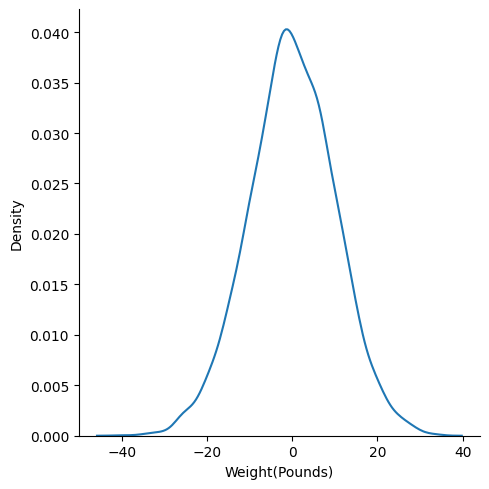

In [67]:
#Plot this residuals
import seaborn as sns
sns.displot(residuals,kind='kde')

Assumpotion:This is a normals distubation.SO iTS A well prediction

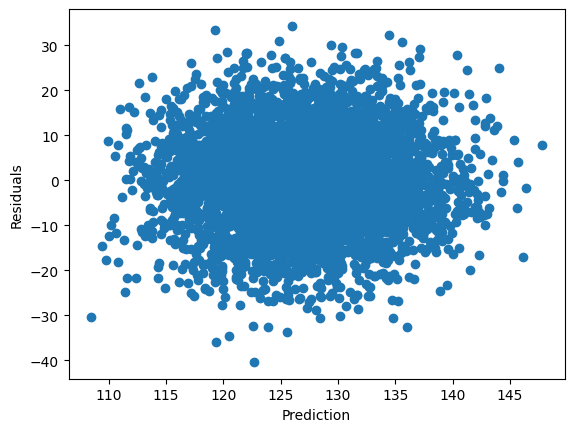

In [68]:
#Scatter plot with respect to prediction and residuals
plt.scatter(y_pred_test,residuals)
plt.xlabel('Prediction')
plt.ylabel('Residuals')
plt.show()

Assumption: This is unifromerly distubuted so its is a better prediction